In [1]:
import pandas as pd
from pathlib import Path


In [2]:
folder = Path.cwd()

In [3]:
spx = pd.read_csv(folder / "spx.csv")

selected_options = pd.read_csv(folder / "spx_selected_option_202502.csv")

options_daily_prices = pd.read_csv(folder / "spx_selected_option_daily_price_202502.csv")



In [4]:
print("Spx shape:", spx.shape)
print("Selected options shape:", selected_options.shape)
print("Daily options prices shape:" , options_daily_prices.shape)

Spx shape: (4258, 11)
Selected options shape: (207, 7)
Daily options prices shape: (4259, 7)


In [5]:
#extra rows, we need to take care of that first
display(
    selected_options[selected_options.isna().any(axis=1)]
)

display(
options_daily_prices[options_daily_prices.isna().any(axis=1)]
)

,leg,target_expiration,target_strike,ask_price,bid_price,old_ask_price,old_bid_price
0,leg_1,4/19/2008,1220.0,4.9,4.1,NaN,NaN
69,leg_2,5/17/2008,1160.0,8.0,7.0,NaN,NaN
138,leg_3,6/21/2008,1100.0,9.5,8.4,NaN,NaN
206,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,date,leg_1_ask,leg_1_bid,leg_2_ask,leg_2_bid,leg_3_ask,leg_3_bid
4258,,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Remove rows only when every column is missing
selected_options = selected_options.dropna(how="all")

# Remove the blank daily-price row
options_daily_prices = options_daily_prices[
    options_daily_prices["date"].str.strip() != ""
].copy()

In [7]:
print("Selected options shape:", selected_options.shape)
print("Daily option prices shape:", options_daily_prices.shape)

Selected options shape: (206, 7)
Daily option prices shape: (4258, 7)


In [8]:
spx["date"] = pd.to_datetime(spx["date"])

selected_options["target_expiration"] = pd.to_datetime(
    selected_options["target_expiration"]
)

options_daily_prices["date"] = pd.to_datetime(
    options_daily_prices["date"]
)

print(spx["date"].dtype)
print(selected_options["target_expiration"].dtype)
print(options_daily_prices["date"].dtype)

datetime64[us]
datetime64[us]
datetime64[us]


In [9]:
dates_match = spx["date"].equals(options_daily_prices["date"])

print("Do the dates match?", dates_match)

Do the dates match? True


In [10]:
masterdates = spx["date"].copy()

print(masterdates.iloc[0])
print(masterdates.iloc[-1])
print(len(masterdates))

2008-03-31 00:00:00
2025-02-28 00:00:00
4258


In [11]:
from datetime import date, datetime

In [12]:
def get_month_nth_weekday(year, month, week, day):
    target_date = date(year, month, (week -1) * 7 + 1)
    temp = target_date.weekday()
    if temp != day:
        target_date = target_date.replace(
            day=(week-1) * 7 + 1 + (day - temp) % 7
        )
    return target_date

In [13]:
def get_target_date_masterdates(masterdates, target_date):
    i=0
    target_date = pd.Timestamp(target_date)
    while target_date >= masterdates[i]:
        i += 1
        
        if i > len(masterdates) -1:
            return datetime.strptime("2040-12-31", "%Y-%m-%d").date()
        
    target_date = masterdates[i - 1]
    
    return target_date

In [14]:
third_friday = get_month_nth_weekday(2008,4,3,4)

print(third_friday)

2008-04-18


In [15]:
matched_date = get_target_date_masterdates(masterdates, third_friday)

print(matched_date)

2008-04-18 00:00:00


In [16]:
check_expirations = selected_options[
    selected_options["target_expiration"].dt.year.isin([2014,2015,2016])
    ][["leg", "target_expiration"]].copy()

check_expirations["weekday"] = check_expirations["target_expiration"].dt.day_name()

display(check_expirations)

,leg,target_expiration,weekday
23,leg_1,2014-01-18,Saturday
24,leg_1,2014-04-19,Saturday
25,leg_1,2014-07-19,Saturday
26,leg_1,2014-10-18,Saturday
27,leg_1,2015-01-17,Saturday
28,leg_1,2015-04-17,Friday
29,leg_1,2015-07-17,Friday
30,leg_1,2015-10-16,Friday
31,leg_1,2016-01-15,Friday
32,leg_1,2016-04-15,Friday


In [17]:
check_expirations["matched_trading_date"] = check_expirations[
    "target_expiration"
].apply(lambda x: get_target_date_masterdates(masterdates, x))

display(check_expirations)

,leg,target_expiration,weekday,matched_trading_date
23,leg_1,2014-01-18,Saturday,2014-01-17
24,leg_1,2014-04-19,Saturday,2014-04-17
25,leg_1,2014-07-19,Saturday,2014-07-18
26,leg_1,2014-10-18,Saturday,2014-10-17
27,leg_1,2015-01-17,Saturday,2015-01-16
28,leg_1,2015-04-17,Friday,2015-04-17
29,leg_1,2015-07-17,Friday,2015-07-17
30,leg_1,2015-10-16,Friday,2015-10-16
31,leg_1,2016-01-15,Friday,2016-01-15
32,leg_1,2016-04-15,Friday,2016-04-15


In [18]:
def get_dates_by_daysoff(masterdates, target_date, offset):
    target_date = pd.Timestamp(target_date)
    target_index = masterdates[masterdates == target_date].index[0]
    new_index = target_index + offset
    new_date = masterdates.iloc[new_index]
    return new_date

In [19]:
roll_date = get_dates_by_daysoff(masterdates, matched_date, -1)
print(roll_date)

2008-04-17 00:00:00


In [20]:
def get_roll_date(masterdates, expiration_date):
    expiration_trading_date = get_target_date_masterdates(
        masterdates,
        expiration_date
    )

    roll_date = get_dates_by_daysoff(
        masterdates,
        expiration_trading_date,
        -1
    )

    return roll_date

In [21]:
test_roll_date = get_roll_date(
    masterdates,
    pd.Timestamp("2015-04-17")
)

print(test_roll_date)
print(test_roll_date.day_name())

2015-04-16 00:00:00
Thursday


### Roll-date calculation
The earlier unrestricted roll-date calculation was removed because the option file includes expirations after the SPX sample ends. The corrected calculation appears below.


In [22]:
print("Last master date:", masterdates.max())
print(selected_options[selected_options["target_expiration"] > masterdates.max()][["leg", "target_expiration"]])

Last master date: 2025-02-28 00:00:00
       leg target_expiration
68   leg_1        2025-04-17
137  leg_2        2025-05-16
205  leg_3        2025-03-21


In [23]:
selected_options["roll_date"] = selected_options["target_expiration"].apply(
    lambda expiration: get_roll_date(masterdates, expiration)
    if expiration <= masterdates.max()
    else pd.NaT
)

selected_options[["leg", "target_expiration", "roll_date"]].tail(6)

,leg,target_expiration,roll_date
200,leg_3,2023-12-15,2023-12-14
201,leg_3,2024-03-15,2024-03-14
202,leg_3,2024-06-21,2024-06-20
203,leg_3,2024-09-20,2024-09-19
204,leg_3,2024-12-20,2024-12-19
205,leg_3,2025-03-21,NaT


In [24]:
selected_options[
    selected_options["roll_date"].isna()
][["leg", "target_expiration", "roll_date"]]

,leg,target_expiration,roll_date
68,leg_1,2025-04-17,NaT
137,leg_2,2025-05-16,NaT
205,leg_3,2025-03-21,NaT


In [25]:
start_value= 100

option_budget = start_value * 0.005

total_option_budget = option_budget * 3

spx_budget = start_value - total_option_budget

print(total_option_budget)
print(spx_budget)

1.5
98.5


In [26]:
start_date = pd.Timestamp("2008-03-31")
start_spx_price = spx.loc[spx["date"] == start_date, "closeprice"].iloc[0]

print(start_spx_price)

1322.699951171875


In [27]:
spx_units= spx_budget / start_spx_price

print(spx_units)

0.07446889214196445


In [28]:
starting_row = options_daily_prices[
    options_daily_prices["date"] == start_date
].iloc[0]

starting_option_units = {
    "leg_1": option_budget / starting_row["leg_1_ask"],
    "leg_2": option_budget / starting_row["leg_2_ask"],
    "leg_3": option_budget / starting_row["leg_3_ask"]
}

starting_option_units

{'leg_1': np.float64(0.1020408163265306),
 'leg_2': np.float64(0.0625),
 'leg_3': np.float64(0.05263157894736842)}

In [29]:
print(options_daily_prices.columns.tolist())

['date', 'leg_1_ask', 'leg_1_bid', 'leg_2_ask', 'leg_2_bid', 'leg_3_ask', 'leg_3_bid']


In [30]:
starting_row = options_daily_prices[
    options_daily_prices["date"] == start_date
].iloc[0]

leg_1_units = option_budget / starting_row["leg_1_ask"]
leg_2_units = option_budget / starting_row["leg_2_ask"]
leg_3_units = option_budget / starting_row["leg_3_ask"]

print("leg_1 units:", leg_1_units)
print("leg_2 units:", leg_2_units)
print("leg_3 units:", leg_3_units)

leg_1 units: 0.1020408163265306
leg_2 units: 0.0625
leg_3 units: 0.05263157894736842


In [31]:
print(leg_1_units * starting_row["leg_1_ask"])
print(leg_2_units * starting_row["leg_2_ask"])
print(leg_3_units * starting_row["leg_3_ask"])

0.5
0.5
0.5


In [32]:
initial_portfolio_value = (
    spx_units * start_spx_price
    + leg_1_units * starting_row["leg_1_ask"]
    + leg_2_units * starting_row["leg_2_ask"]
    + leg_3_units * starting_row["leg_3_ask"]
)

print(initial_portfolio_value)

100.0


In [33]:
next_date = pd.Timestamp("2008-04-01")

next_row = options_daily_prices[
    options_daily_prices["date"] == next_date
].iloc[0]

In [34]:
leg_1_mark = (next_row["leg_1_bid"] + next_row["leg_1_ask"]) / 2
leg_2_mark = (next_row["leg_2_bid"] + next_row["leg_2_ask"]) / 2
leg_3_mark = (next_row["leg_3_bid"] + next_row["leg_3_ask"]) / 2

In [35]:
leg_1_value = leg_1_units * leg_1_mark
leg_2_value = leg_2_units * leg_2_mark
leg_3_value = leg_3_units * leg_3_mark

leg_1_value = leg_1_units * leg_1_mark
leg_2_value = leg_2_units * leg_2_mark
leg_3_value = leg_3_units * leg_3_mark

print("leg_1 value:", leg_1_value)
print("leg_2 value:", leg_2_value)
print("leg_3 value:", leg_3_value)

leg_1 value: 0.11224489795918367
leg_2 value: 0.1796875
leg_3 value: 0.2552631578947368


In [36]:
next_spx_price = spx.loc[
    spx["date"] == next_date,
    "closeprice"
].iloc[0]

next_spx_value = spx_units * next_spx_price

In [37]:
next_portfolio_value = (
    next_spx_value
    + leg_1_value
    + leg_2_value
    + leg_3_value
)

print(next_portfolio_value)

102.58298619072478


In [38]:
portfolio = pd.DataFrame({
    "date": masterdates,
    "portfolio_value": None
})

In [39]:
portfolio.loc[0, "portfolio_value"] = initial_portfolio_value

In [40]:
for i in range(1, 14):
    current_row = options_daily_prices.iloc[i]
    current_spx_price = spx.iloc[i]["closeprice"]
    current_leg_1_mark = (
        current_row["leg_1_bid"] + current_row["leg_1_ask"]
    ) / 2

    current_leg_2_mark = (
        current_row["leg_2_bid"] + current_row["leg_2_ask"]
    ) / 2

    current_leg_3_mark = (
        current_row["leg_3_bid"] + current_row["leg_3_ask"]
    ) / 2
    
    current_portfolio_value = (
        spx_units * current_spx_price
        + leg_1_units * current_leg_1_mark
        + leg_2_units * current_leg_2_mark
        + leg_3_units * current_leg_3_mark
    )

    portfolio.loc[i, "portfolio_value"] = current_portfolio_value

In [41]:
print(portfolio.loc[1, "portfolio_value"])
print(next_portfolio_value)

102.58298619072478
102.58298619072478


In [42]:
print(portfolio.loc[13, "date"])
print(portfolio.loc[13, "portfolio_value"])

2008-04-17 00:00:00
102.7271770476197


In [43]:
roll_portfolio_value = portfolio.loc[13, "portfolio_value"]
new_leg_1_budget = roll_portfolio_value * 0.005

In [44]:
print(selected_options.columns.tolist())

['leg', 'target_expiration', 'target_strike', 'ask_price', 'bid_price', 'old_ask_price', 'old_bid_price', 'roll_date']


In [45]:
leg_1_roll_row = selected_options[
    (selected_options["leg"] == "leg_1")
    & (selected_options["roll_date"] == pd.Timestamp("2008-04-17"))
].iloc[0]

old_leg_1_mark = (
    leg_1_roll_row["old_bid_price"]
    + leg_1_roll_row["old_ask_price"]
) / 2

old_leg_1_sale_proceeds = leg_1_units * old_leg_1_mark

In [46]:
print(
    leg_1_roll_row[
        [
            "target_expiration",
            "target_strike",
            "ask_price",
            "old_ask_price",
            "old_bid_price",
            "roll_date"
        ]
    ]
)

target_expiration    2008-04-19 00:00:00
target_strike                     1220.0
ask_price                            4.9
old_ask_price                        NaN
old_bid_price                        NaN
roll_date            2008-04-17 00:00:00
Name: 0, dtype: object


In [47]:
selected_options[
    selected_options["leg"] == "leg_1"
].head(3)

,leg,target_expiration,target_strike,ask_price,bid_price,old_ask_price,old_bid_price,roll_date
0,leg_1,2008-04-19,1220.0,4.9,4.1,NaN,NaN,2008-04-17
1,leg_1,2008-07-19,1150.0,8.9,7.9,1.0,0.00,2008-07-17
2,leg_1,2008-10-18,1050.0,9.7,8.7,0.1,0.05,2008-10-16


In [48]:
leg_1_replacement_row = selected_options[
    selected_options["leg"] == "leg_1"
].iloc[1]

old_leg_1_mark = (
    leg_1_replacement_row["old_bid_price"]
    + leg_1_replacement_row["old_ask_price"]
) / 2

old_leg_1_sale_proceeds = leg_1_units * old_leg_1_mark

In [49]:
new_leg_1_units = (
    new_leg_1_budget
    / leg_1_replacement_row["ask_price"]
)

In [50]:
roll_spx_price = spx.loc[
    spx["date"] == pd.Timestamp("2008-04-17"),
    "closeprice"
].iloc[0]

spx_units = spx_units + (
    old_leg_1_sale_proceeds - new_leg_1_budget
) / roll_spx_price

In [51]:
leg_1_units = new_leg_1_units

In [52]:
post_roll_portfolio_value = (
    spx_units * roll_spx_price
    + leg_1_units * leg_1_replacement_row["ask_price"]
    + leg_2_units * current_leg_2_mark
    + leg_3_units * current_leg_3_mark
)

print(roll_portfolio_value)
print(post_roll_portfolio_value)

102.7271770476197
101.9210545986401


In [53]:
correct_roll_portfolio_value = (
    spx_units * roll_spx_price
    + new_leg_1_budget
    + leg_2_units * current_leg_2_mark
    + leg_3_units * current_leg_3_mark
)

print(correct_roll_portfolio_value)

101.9210545986401


In [54]:
spx_units = spx_budget / start_spx_price

leg_1_units = option_budget / starting_row["leg_1_ask"]
leg_2_units = option_budget / starting_row["leg_2_ask"]
leg_3_units = option_budget / starting_row["leg_3_ask"]

In [55]:
roll_portfolio_value = (
    spx_units * roll_spx_price
    + leg_1_units * old_leg_1_mark
    + leg_2_units * current_leg_2_mark
    + leg_3_units * current_leg_3_mark
)

new_leg_1_budget = roll_portfolio_value * 0.005

print(roll_portfolio_value)
print("SPX price:", roll_spx_price)
print("Old leg 1 mark:", old_leg_1_mark)
print("Leg 2 mark:", current_leg_2_mark)
print("Leg 3 mark:", current_leg_3_mark)
print("Correct roll value:", roll_portfolio_value)

101.92105459864011
SPX price: 1365.56005859375
Old leg 1 mark: 0.5
Leg 2 mark: 1.0
Leg 3 mark: 2.2
Correct roll value: 101.92105459864011


In [56]:
new_leg_1_budget = roll_portfolio_value * 0.005

old_leg_1_sale_proceeds = leg_1_units * old_leg_1_mark

new_leg_1_units = (
    new_leg_1_budget
    / leg_1_replacement_row["ask_price"]
)

In [57]:
spx_units = spx_units + (
    old_leg_1_sale_proceeds - new_leg_1_budget
) / roll_spx_price

leg_1_units = new_leg_1_units

In [58]:
post_roll_portfolio_value = (
    spx_units * roll_spx_price
    + leg_1_units * leg_1_replacement_row["ask_price"]
    + leg_2_units * current_leg_2_mark
    + leg_3_units * current_leg_3_mark
)

print(roll_portfolio_value)
print(post_roll_portfolio_value)

101.92105459864011
101.9210545986401


In [59]:
portfolio.loc[13, "portfolio_value"] = roll_portfolio_value

In [60]:
next_roll_date = selected_options.loc[
    selected_options["roll_date"] > pd.Timestamp("2008-04-17"),
    "roll_date"
].min()

print(next_roll_date)

2008-05-15 00:00:00


In [61]:
next_roll_index = portfolio[
    portfolio["date"] == next_roll_date
].index[0]

print(next_roll_index)

33


In [62]:
for i in range(14, next_roll_index):
    current_row = options_daily_prices.iloc[i]
    current_spx_price = spx.iloc[i]["closeprice"]

    current_leg_1_mark = (
        current_row["leg_1_bid"] + current_row["leg_1_ask"]
    ) / 2

    current_leg_2_mark = (
        current_row["leg_2_bid"] + current_row["leg_2_ask"]
    ) / 2

    current_leg_3_mark = (
        current_row["leg_3_bid"] + current_row["leg_3_ask"]
    ) / 2

    current_portfolio_value = (
        spx_units * current_spx_price
        + leg_1_units * current_leg_1_mark
        + leg_2_units * current_leg_2_mark
        + leg_3_units * current_leg_3_mark
    )

    portfolio.loc[i, "portfolio_value"] = current_portfolio_value

In [63]:
leg_2_replacement_row = selected_options[
    selected_options["leg"] == "leg_2"
].iloc[1]

old_leg_2_mark = (
    leg_2_replacement_row["old_bid_price"]
    + leg_2_replacement_row["old_ask_price"]
) / 2

roll_row = options_daily_prices.iloc[next_roll_index]
roll_spx_price = spx.iloc[next_roll_index]["closeprice"]

roll_leg_1_mark = (
    roll_row["leg_1_bid"] + roll_row["leg_1_ask"]
) / 2

roll_leg_3_mark = (
    roll_row["leg_3_bid"] + roll_row["leg_3_ask"]
) / 2

In [64]:
# Reset the portfolio to its original March 31, 2008 holdings
portfolio = pd.DataFrame({
    "date": masterdates,
    "portfolio_value": None
})

spx_units = spx_budget / start_spx_price

leg_units = {
    "leg_1": option_budget / starting_row["leg_1_ask"],
    "leg_2": option_budget / starting_row["leg_2_ask"],
    "leg_3": option_budget / starting_row["leg_3_ask"]
}

# Each pointer identifies the option currently held for that leg
leg_pointer = {
    "leg_1": 0,
    "leg_2": 0,
    "leg_3": 0
}

leg_tables = {
    leg: selected_options[
        selected_options["leg"] == leg
    ].reset_index(drop=True)
    for leg in ["leg_1", "leg_2", "leg_3"]
}

roll_log = []

portfolio.loc[0, "portfolio_value"] = 100.0

for i in range(1, len(masterdates)):
    current_date = masterdates.iloc[i]
    current_spx_price = spx.iloc[i]["closeprice"]
    current_prices = options_daily_prices.iloc[i]

    daily_marks = {
        leg: (
            current_prices[f"{leg}_bid"]
            + current_prices[f"{leg}_ask"]
        ) / 2
        for leg in ["leg_1", "leg_2", "leg_3"]
    }

    rolling_leg = None

    # Check whether one of the three legs rolls today
    for leg in ["leg_1", "leg_2", "leg_3"]:
        current_contract = leg_tables[leg].iloc[
            leg_pointer[leg]
        ]

        if current_contract["roll_date"] == current_date:
            rolling_leg = leg
            break

    if rolling_leg is None:
        # Normal non-roll trading day
        portfolio_value = (
            spx_units * current_spx_price
            + leg_units["leg_1"] * daily_marks["leg_1"]
            + leg_units["leg_2"] * daily_marks["leg_2"]
            + leg_units["leg_3"] * daily_marks["leg_3"]
        )

    else:
        current_pointer = leg_pointer[rolling_leg]
        replacement_pointer = current_pointer + 1

        replacement_row = leg_tables[rolling_leg].iloc[
            replacement_pointer
        ]

        old_mark = (
            replacement_row["old_bid_price"]
            + replacement_row["old_ask_price"]
        ) / 2

        # Value the portfolio immediately before replacing the old put
        portfolio_value = spx_units * current_spx_price

        for leg in ["leg_1", "leg_2", "leg_3"]:
            if leg == rolling_leg:
                portfolio_value += leg_units[leg] * old_mark
            else:
                portfolio_value += leg_units[leg] * daily_marks[leg]

        new_option_budget = portfolio_value * 0.005
        old_sale_proceeds = leg_units[rolling_leg] * old_mark

        new_units = (
            new_option_budget
            / replacement_row["ask_price"]
        )

        # Fund the net option cash flow through the SPX position
        spx_units += (
            old_sale_proceeds - new_option_budget
        ) / current_spx_price

        leg_units[rolling_leg] = new_units
        leg_pointer[rolling_leg] = replacement_pointer

        roll_log.append({
            "date": current_date,
            "leg": rolling_leg,
            "old_mark": old_mark,
            "new_ask": replacement_row["ask_price"],
            "new_budget": new_option_budget,
            "portfolio_value": portfolio_value
        })

    portfolio.loc[i, "portfolio_value"] = portfolio_value

In [65]:
print("Rows:", len(portfolio))
print("Missing values:", portfolio["portfolio_value"].isna().sum())
print("Rolls completed:", len(roll_log))
print("Final date:", portfolio.iloc[-1]["date"])
print("Final portfolio value:", portfolio.iloc[-1]["portfolio_value"])

Rows: 4258
Missing values: 0
Rolls completed: 203
Final date: 2025-02-28 00:00:00
Final portfolio value: 319.3041280256207


In [66]:
roll_log_df = pd.DataFrame(roll_log)

print(roll_log_df.head())
print()
print(roll_log_df.tail())

        date    leg  old_mark  new_ask  new_budget  portfolio_value
0 2008-04-17  leg_1     0.500      8.9    0.509605       101.921055
1 2008-05-15  leg_2     0.025      9.0    0.528283       105.656661
2 2008-06-19  leg_3     0.025      9.6    0.499370        99.873911
3 2008-07-17  leg_1     0.075      9.7    0.471743        94.348573
4 2008-08-14  leg_2     0.125     10.1    0.473112        94.622472

          date    leg  old_mark  new_ask  new_budget  portfolio_value
198 2024-10-17  leg_1     0.050     34.7    1.594168       318.833570
199 2024-11-14  leg_2     0.075     30.7    1.612710       322.542026
200 2024-12-19  leg_3     0.400     42.6    1.595160       319.032073
201 2025-01-16  leg_1     0.075     32.2    1.594062       318.812365
202 2025-02-20  leg_2     0.075     30.8    1.633531       326.706234


In [67]:
portfolio["portfolio_value"] = pd.to_numeric(
    portfolio["portfolio_value"]
)

portfolio_ts = portfolio.copy()

portfolio_ts = portfolio_ts.set_index("date")

portfolio_ts.index = pd.to_datetime(
    portfolio_ts.index
)

portfolio_ts = portfolio_ts.sort_index()

portfolio_ts.tail()

,portfolio_value
date,
2025-02-24,320.957544
2025-02-25,319.609977
2025-02-26,319.505479
2025-02-27,315.681069
2025-02-28,319.304128


In [68]:
portfolio_ts["daily_return"] = (
    portfolio_ts["portfolio_value"].pct_change()
)

portfolio_ts.tail()

,portfolio_value,daily_return
date,,
2025-02-24,320.957544,-0.004368
2025-02-25,319.609977,-0.004199
2025-02-26,319.505479,-0.000327
2025-02-27,315.681069,-0.011970
2025-02-28,319.304128,0.011477


In [69]:
import numpy as np

In [70]:
daily_returns = portfolio_ts["daily_return"].dropna()

start_portfolio_value = portfolio_ts["portfolio_value"].iloc[0]
end_portfolio_value = portfolio_ts["portfolio_value"].iloc[-1]

total_return = (
    end_portfolio_value / start_portfolio_value
) - 1

years = (
    portfolio_ts.index[-1] - portfolio_ts.index[0]
).days / 365.25

annualized_return = (
    end_portfolio_value / start_portfolio_value
) ** (1 / years) - 1

annualized_volatility = (
    daily_returns.std() * np.sqrt(252)
)

print(f"Total Return: {total_return:.2%}")
print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")


Total Return: 219.30%
Annualized Return: 7.10%
Annualized Volatility: 14.72%


In [71]:
portfolio_ts["running_peak"] = (
    portfolio_ts["portfolio_value"].cummax()
)

portfolio_ts["drawdown"] = (
    portfolio_ts["portfolio_value"]
    / portfolio_ts["running_peak"]
) - 1

maximum_drawdown = portfolio_ts["drawdown"].min()

print(f"Maximum Drawdown: {maximum_drawdown:.2%}")

Maximum Drawdown: -34.71%


In [72]:
maximum_drawdown = portfolio_ts["drawdown"].min()

drawdown_end_date = portfolio_ts["drawdown"].idxmin()

drawdown_start_date = portfolio_ts.loc[
    :drawdown_end_date,
    "portfolio_value"
].idxmax()

print(f"Maximum Drawdown: {maximum_drawdown:.2%}")
print(f"Drawdown Start: {drawdown_start_date.date()}")
print(f"Drawdown Trough: {drawdown_end_date.date()}")

Maximum Drawdown: -34.71%
Drawdown Start: 2008-05-19
Drawdown Trough: 2009-03-09


In [73]:
def historical_var(returns, confidence_level):
    tail_probability = 1 - confidence_level
    return -np.quantile(returns, tail_probability)


historical_var_95 = historical_var(
    daily_returns,
    0.95
)

historical_var_99 = historical_var(
    daily_returns,
    0.99
)

print(f"95% Historical VaR: {historical_var_95:.2%}")
print(f"99% Historical VaR: {historical_var_99:.2%}")

95% Historical VaR: 1.36%
99% Historical VaR: 2.51%


In [74]:
def expected_shortfall(returns, confidence_level):
    tail_probability = 1 - confidence_level
    cutoff_return = np.quantile(
        returns,
        tail_probability
    )

    tail_returns = returns[
        returns <= cutoff_return
    ]

    return -tail_returns.mean()


expected_shortfall_95 = expected_shortfall(
    daily_returns,
    0.95
)

expected_shortfall_99 = expected_shortfall(
    daily_returns,
    0.99
)

print(f"95% Expected Shortfall: {expected_shortfall_95:.2%}")
print(f"99% Expected Shortfall: {expected_shortfall_99:.2%}")

95% Expected Shortfall: 2.13%
99% Expected Shortfall: 3.52%


In [75]:
from scipy.stats import norm

mean_daily_return = daily_returns.mean()
daily_volatility = daily_returns.std()

z_95 = norm.ppf(0.95)
z_99 = norm.ppf(0.99)

variance_covariance_var_95 = -(
    mean_daily_return - z_95 * daily_volatility
)

variance_covariance_var_99 = -(
    mean_daily_return - z_99 * daily_volatility
)

print(
    f"95% Variance-Covariance VaR: "
    f"{variance_covariance_var_95:.2%}"
)

print(
    f"99% Variance-Covariance VaR: "
    f"{variance_covariance_var_99:.2%}"
)

95% Variance-Covariance VaR: 1.49%
99% Variance-Covariance VaR: 2.13%


In [76]:
annual_risk_free_rate = 0.0119

daily_risk_free_rate = (
    1 + annual_risk_free_rate
) ** (1 / 252) - 1

excess_daily_returns = (
    daily_returns - daily_risk_free_rate
)

sharpe_ratio = (
    excess_daily_returns.mean()
    / excess_daily_returns.std()
) * np.sqrt(252)

downside_returns = excess_daily_returns[
    excess_daily_returns < 0
]

sortino_ratio = (
    excess_daily_returns.mean()
    / downside_returns.std()
) * np.sqrt(252)

print(f"Average Annual Risk-Free Rate: {annual_risk_free_rate:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.3f}")
print(f"Sortino Ratio: {sortino_ratio:.3f}")

Average Annual Risk-Free Rate: 1.19%
Sharpe Ratio: 0.460
Sortino Ratio: 0.630


In [77]:
spx_ts = spx[
    ["date", "totalreturn"]
].copy()

spx_ts = spx_ts.set_index("date")

spx_ts.index = pd.to_datetime(
    spx_ts.index
)

spx_ts = spx_ts.sort_index()

spx_ts["daily_return"] = pd.to_numeric(
    spx_ts["totalreturn"]
)

spx_ts["portfolio_value"] = (
    100
    * (1 + spx_ts["daily_return"].fillna(0)).cumprod()
)

spx_ts.tail()

,totalreturn,daily_return,portfolio_value
date,,,
2025-02-24,-0.004969,-0.004969,454.908551
2025-02-25,-0.004680,-0.004680,452.779579
2025-02-26,0.000136,0.000136,452.841157
2025-02-27,-0.015865,-0.015865,445.656832
2025-02-28,0.015854,0.015854,452.722275


In [78]:
spx_daily_returns = spx_ts["daily_return"].dropna()

spx_start_value = spx_ts["portfolio_value"].iloc[0]
spx_end_value = spx_ts["portfolio_value"].iloc[-1]

spx_total_return = (
    spx_end_value / spx_start_value
) - 1

spx_annualized_return = (
    spx_end_value / spx_start_value
) ** (1 / years) - 1

spx_annualized_volatility = (
    spx_daily_returns.std() * np.sqrt(252)
)

spx_ts["running_peak"] = (
    spx_ts["portfolio_value"].cummax()
)

spx_ts["drawdown"] = (
    spx_ts["portfolio_value"]
    / spx_ts["running_peak"]
) - 1

spx_maximum_drawdown = spx_ts["drawdown"].min()

print(f"SPX Total Return: {spx_total_return:.2%}")
print(f"SPX Annualized Return: {spx_annualized_return:.2%}")
print(f"SPX Annualized Volatility: {spx_annualized_volatility:.2%}")
print(f"SPX Maximum Drawdown: {spx_maximum_drawdown:.2%}")

SPX Total Return: 350.16%
SPX Annualized Return: 9.30%
SPX Annualized Volatility: 20.01%
SPX Maximum Drawdown: -52.58%


In [79]:
spx_historical_var_95 = historical_var(
    spx_daily_returns,
    0.95
)

spx_historical_var_99 = historical_var(
    spx_daily_returns,
    0.99
)

spx_expected_shortfall_95 = expected_shortfall(
    spx_daily_returns,
    0.95
)

spx_expected_shortfall_99 = expected_shortfall(
    spx_daily_returns,
    0.99
)

print(f"SPX 95% Historical VaR: {spx_historical_var_95:.2%}")
print(f"SPX 99% Historical VaR: {spx_historical_var_99:.2%}")
print(f"SPX 95% Expected Shortfall: {spx_expected_shortfall_95:.2%}")
print(f"SPX 99% Expected Shortfall: {spx_expected_shortfall_99:.2%}")

SPX 95% Historical VaR: 1.86%
SPX 99% Historical VaR: 3.71%
SPX 95% Expected Shortfall: 3.12%
SPX 99% Expected Shortfall: 5.45%


In [80]:
spx_mean_daily_return = spx_daily_returns.mean()
spx_daily_volatility = spx_daily_returns.std()

spx_variance_covariance_var_95 = -(
    spx_mean_daily_return - z_95 * spx_daily_volatility
)

spx_variance_covariance_var_99 = -(
    spx_mean_daily_return - z_99 * spx_daily_volatility
)

print(
    f"SPX 95% Variance-Covariance VaR: "
    f"{spx_variance_covariance_var_95:.2%}"
)

print(
    f"SPX 99% Variance-Covariance VaR: "
    f"{spx_variance_covariance_var_99:.2%}"
)

SPX 95% Variance-Covariance VaR: 2.03%
SPX 99% Variance-Covariance VaR: 2.89%


In [81]:
spx_excess_daily_returns = (
    spx_daily_returns - daily_risk_free_rate
)

spx_sharpe_ratio = (
    spx_excess_daily_returns.mean()
    / spx_excess_daily_returns.std()
) * np.sqrt(252)

spx_downside_returns = spx_excess_daily_returns[
    spx_excess_daily_returns < 0
]

spx_sortino_ratio = (
    spx_excess_daily_returns.mean()
    / spx_downside_returns.std()
) * np.sqrt(252)

print(f"SPX Sharpe Ratio: {spx_sharpe_ratio:.3f}")
print(f"SPX Sortino Ratio: {spx_sortino_ratio:.3f}")

SPX Sharpe Ratio: 0.488
SPX Sortino Ratio: 0.591


In [82]:
comparison_table = pd.DataFrame({
    "Metric": [
        "Total Return",
        "Annualized Return",
        "Annualized Volatility",
        "Maximum Drawdown",
        "95% Historical VaR",
        "99% Historical VaR",
        "95% Expected Shortfall",
        "99% Expected Shortfall",
        "95% Variance-Covariance VaR",
        "99% Variance-Covariance VaR",
        "Sharpe Ratio",
        "Sortino Ratio"
    ],
    "Tail Hedge Portfolio": [
        total_return,
        annualized_return,
        annualized_volatility,
        maximum_drawdown,
        historical_var_95,
        historical_var_99,
        expected_shortfall_95,
        expected_shortfall_99,
        variance_covariance_var_95,
        variance_covariance_var_99,
        sharpe_ratio,
        sortino_ratio
    ],
    "Unhedged SPX": [
        spx_total_return,
        spx_annualized_return,
        spx_annualized_volatility,
        spx_maximum_drawdown,
        spx_historical_var_95,
        spx_historical_var_99,
        spx_expected_shortfall_95,
        spx_expected_shortfall_99,
        spx_variance_covariance_var_95,
        spx_variance_covariance_var_99,
        spx_sharpe_ratio,
        spx_sortino_ratio
    ]
})

comparison_table

,Metric,Tail Hedge Portfolio,Unhedged SPX
0,Total Return,2.193041,3.501622
1,Annualized Return,0.071048,0.093019
2,Annualized Volatility,0.147194,0.200076
3,Maximum Drawdown,-0.347060,-0.525786
4,95% Historical VaR,0.013591,0.018600
5,99% Historical VaR,0.025107,0.037057
6,95% Expected Shortfall,0.021265,0.031158
7,99% Expected Shortfall,0.035210,0.054479
8,95% Variance-Covariance VaR,0.014936,0.020297
9,99% Variance-Covariance VaR,0.021255,0.028886


In [83]:
crisis_periods = {
    "2008-2009 Financial Crisis": (
        "2008-03-31",
        "2009-12-31"
    ),
    "2020 COVID Crisis": (
        "2020-01-01",
        "2020-12-31"
    ),
    "2022 Rate Hike / Inflation": (
        "2022-01-01",
        "2022-12-31"
    )
}

crisis_results = []

for period_name, (start_date, end_date) in crisis_periods.items():

    hedge_period = portfolio_ts.loc[
        start_date:end_date
    ].copy()

    spx_period = spx_ts.loc[
        start_date:end_date
    ].copy()

    hedge_period_return = (
        hedge_period["portfolio_value"].iloc[-1]
        / hedge_period["portfolio_value"].iloc[0]
    ) - 1

    spx_period_return = (
        spx_period["portfolio_value"].iloc[-1]
        / spx_period["portfolio_value"].iloc[0]
    ) - 1

    hedge_period_max_drawdown = (
        hedge_period["portfolio_value"]
        / hedge_period["portfolio_value"].cummax()
        - 1
    ).min()

    spx_period_max_drawdown = (
        spx_period["portfolio_value"]
        / spx_period["portfolio_value"].cummax()
        - 1
    ).min()

    crisis_results.append({
        "Period": period_name,
        "Tail Hedge Return": hedge_period_return,
        "SPX Return": spx_period_return,
        "Tail Hedge Max Drawdown": hedge_period_max_drawdown,
        "SPX Max Drawdown": spx_period_max_drawdown
    })

crisis_comparison = pd.DataFrame(crisis_results)

crisis_comparison

,Period,Tail Hedge Return,SPX Return,Tail Hedge Max Drawdown,SPX Max Drawdown
0,2008-2009 Financial Crisis,0.069784,-0.156956,-0.347060,-0.525786
1,2020 COVID Crisis,0.384539,0.152927,-0.122089,-0.339251
2,2022 Rate Hike / Inflation,-0.243300,-0.199534,-0.260016,-0.254252


In [84]:
crisis_comparison["Return Difference"] = (
    crisis_comparison["Tail Hedge Return"]
    - crisis_comparison["SPX Return"]
)

crisis_comparison["Drawdown Reduction"] = (
    crisis_comparison["SPX Max Drawdown"]
    - crisis_comparison["Tail Hedge Max Drawdown"]
)

crisis_comparison

,Period,Tail Hedge Return,SPX Return,Tail Hedge Max Drawdown,SPX Max Drawdown,Return Difference,Drawdown Reduction
0,2008-2009 Financial Crisis,0.069784,-0.156956,-0.347060,-0.525786,0.226740,-0.178726
1,2020 COVID Crisis,0.384539,0.152927,-0.122089,-0.339251,0.231612,-0.217162
2,2022 Rate Hike / Inflation,-0.243300,-0.199534,-0.260016,-0.254252,-0.043766,0.005764


In [85]:
cost_units = {
    "leg_1": option_budget / starting_row["leg_1_ask"],
    "leg_2": option_budget / starting_row["leg_2_ask"],
    "leg_3": option_budget / starting_row["leg_3_ask"]
}

protection_cost_records = []

for _, roll in roll_log_df.iterrows():

    leg = roll["leg"]

    old_sale_proceeds = (
        cost_units[leg] * roll["old_mark"]
    )

    new_option_cost = roll["new_budget"]

    net_protection_cost = (
        new_option_cost - old_sale_proceeds
    )

    protection_cost_records.append({
        "date": roll["date"],
        "leg": leg,
        "new_option_cost": new_option_cost,
        "old_sale_proceeds": old_sale_proceeds,
        "net_protection_cost": net_protection_cost
    })

    cost_units[leg] = (
        new_option_cost / roll["new_ask"]
    )

protection_cost_df = pd.DataFrame(
    protection_cost_records
)

protection_cost_df.tail()

,date,leg,new_option_cost,old_sale_proceeds,net_protection_cost
198,2024-10-17,leg_1,1.594168,0.002716,1.591452
199,2024-11-14,leg_2,1.612710,0.003824,1.608886
200,2024-12-19,leg_3,1.595160,0.018752,1.576408
201,2025-01-16,leg_1,1.594062,0.003446,1.590616
202,2025-02-20,leg_2,1.633531,0.003940,1.629591


In [86]:
total_net_protection_cost = (
    protection_cost_df["net_protection_cost"].sum()
)

average_annual_protection_cost = (
    total_net_protection_cost / years
)

average_annual_cost_pct_of_start = (
    average_annual_protection_cost / start_portfolio_value
)

average_cost_per_roll = (
    protection_cost_df["net_protection_cost"].mean()
)

print(
    f"Total Net Protection Cost: "
    f"{total_net_protection_cost:.4f}"
)

print(
    f"Average Annual Protection Cost: "
    f"{average_annual_protection_cost:.4f}"
)

print(
    f"Average Annual Cost as % of Starting Portfolio: "
    f"{average_annual_cost_pct_of_start:.2%}"
)

print(
    f"Average Net Cost per Roll: "
    f"{average_cost_per_roll:.4f}"
)

Total Net Protection Cost: 98.3989
Average Annual Protection Cost: 5.8174
Average Annual Cost as % of Starting Portfolio: 5.82%
Average Net Cost per Roll: 0.4847


In [87]:
protection_cost_df["year"] = (
    protection_cost_df["date"].dt.year
)

annual_protection_cost = (
    protection_cost_df
    .groupby("year")["net_protection_cost"]
    .sum()
    .reset_index()
)

annual_protection_cost = annual_protection_cost.rename(
    columns={
        "net_protection_cost": "annual_net_protection_cost"
    }
)

annual_protection_cost.tail()

,year,annual_net_protection_cost
13,2021,16.976053
14,2022,14.898127
15,2023,15.168804
16,2024,18.042796
17,2025,3.220208


In [88]:
annual_returns = pd.DataFrame({
    "Tail Hedge Return": (
        portfolio_ts["portfolio_value"]
        .resample("YE")
        .last()
        .pct_change()
    ),
    "SPX Return": (
        spx_ts["portfolio_value"]
        .resample("YE")
        .last()
        .pct_change()
    )
})

annual_returns = annual_returns.dropna()

annual_returns.tail()

,Tail Hedge Return,SPX Return
date,,
2021-12-31,0.193582,0.268914
2022-12-31,-0.239086,-0.194432
2023-12-31,0.168285,0.242292
2024-12-31,0.162459,0.233083
2025-12-31,0.007863,0.012386


In [89]:
annual_returns["Outperformance"] = (
    annual_returns["Tail Hedge Return"]
    - annual_returns["SPX Return"]
)

annual_returns["Hedge Beat SPX"] = (
    annual_returns["Outperformance"] > 0
)

years_hedge_outperformed = (
    annual_returns["Hedge Beat SPX"].sum()
)

total_years = len(annual_returns)

outperformance_rate = (
    years_hedge_outperformed / total_years
)

print(
    f"Years Hedge Outperformed SPX: "
    f"{years_hedge_outperformed} of {total_years}"
)

print(
    f"Outperformance Rate: "
    f"{outperformance_rate:.2%}"
)

annual_returns.tail()

Years Hedge Outperformed SPX: 2 of 17
Outperformance Rate: 11.76%


,Tail Hedge Return,SPX Return,Outperformance,Hedge Beat SPX
date,,,,
2021-12-31,0.193582,0.268914,-0.075332,False
2022-12-31,-0.239086,-0.194432,-0.044654,False
2023-12-31,0.168285,0.242292,-0.074007,False
2024-12-31,0.162459,0.233083,-0.070624,False
2025-12-31,0.007863,0.012386,-0.004523,False


In [90]:
segments = {
    "2008-2009 Financial Crisis": (
        "2008-03-31",
        "2009-12-31"
    ),
    "2010-2019 Expansion": (
        "2010-01-01",
        "2019-12-31"
    ),
    "2020-2021 COVID and Rebound": (
        "2020-01-01",
        "2021-12-31"
    ),
    "2022 Rate Hike and Inflation": (
        "2022-01-01",
        "2022-12-31"
    ),
    "2023-2025 Recent Period": (
        "2023-01-01",
        "2025-02-28"
    )
}

segmented_results = []

for segment_name, (start_date, end_date) in segments.items():

    hedge_segment_returns = portfolio_ts.loc[
        start_date:end_date,
        "daily_return"
    ].dropna()

    spx_segment_returns = spx_ts.loc[
        start_date:end_date,
        "daily_return"
    ].dropna()

    segmented_results.append({
        "Period": segment_name,

        "Tail Hedge 95% VaR": historical_var(
            hedge_segment_returns,
            0.95
        ),

        "Tail Hedge 99% VaR": historical_var(
            hedge_segment_returns,
            0.99
        ),

        "SPX 95% VaR": historical_var(
            spx_segment_returns,
            0.95
        ),

        "SPX 99% VaR": historical_var(
            spx_segment_returns,
            0.99
        )
    })

segmented_var_table = pd.DataFrame(
    segmented_results
)

segmented_var_table

,Period,Tail Hedge 95% VaR,Tail Hedge 99% VaR,SPX 95% VaR,SPX 99% VaR
0,2008-2009 Financial Crisis,0.024344,0.042603,0.037553,0.064498
1,2010-2019 Expansion,0.011207,0.018642,0.015406,0.028143
2,2020-2021 COVID and Rebound,0.014427,0.032698,0.022586,0.048680
3,2022 Rate Hike and Inflation,0.021280,0.029022,0.026371,0.037527
4,2023-2025 Recent Period,0.010829,0.015200,0.013789,0.018553


In [91]:
rolling_window = 250

portfolio_ts["rolling_hvar_95"] = (
    portfolio_ts["daily_return"]
    .rolling(rolling_window)
    .apply(
        lambda x: historical_var(x, 0.95),
        raw=False
    )
)

portfolio_ts["rolling_hvar_99"] = (
    portfolio_ts["daily_return"]
    .rolling(rolling_window)
    .apply(
        lambda x: historical_var(x, 0.99),
        raw=False
    )
)

spx_ts["rolling_hvar_95"] = (
    spx_ts["daily_return"]
    .rolling(rolling_window)
    .apply(
        lambda x: historical_var(x, 0.95),
        raw=False
    )
)

spx_ts["rolling_hvar_99"] = (
    spx_ts["daily_return"]
    .rolling(rolling_window)
    .apply(
        lambda x: historical_var(x, 0.99),
        raw=False
    )
)

print("Tail hedge rolling VaR:")
print(portfolio_ts[
    ["rolling_hvar_95", "rolling_hvar_99"]
].tail())

print()

print("SPX rolling VaR:")
print(spx_ts[
    ["rolling_hvar_95", "rolling_hvar_99"]
].tail())

Tail hedge rolling VaR:
            rolling_hvar_95  rolling_hvar_99
date                                        
2025-02-24         0.010539         0.015709
2025-02-25         0.010539         0.015709
2025-02-26         0.010539         0.015709
2025-02-27         0.011374         0.015709
2025-02-28         0.011374         0.015709

SPX rolling VaR:
            rolling_hvar_95  rolling_hvar_99
date                                        
2025-02-24         0.013823          0.02217
2025-02-25         0.013823          0.02217
2025-02-26         0.013823          0.02217
2025-02-27         0.014271          0.02217
2025-02-28         0.014271          0.02217


In [92]:
portfolio_ts["tail_event_95"] = (
    portfolio_ts["daily_return"]
    <= -historical_var_95
)

spx_ts["tail_event_95"] = (
    spx_ts["daily_return"]
    <= -spx_historical_var_95
)

annual_tail_events = pd.DataFrame({
    "Tail Hedge Tail Events": (
        portfolio_ts["tail_event_95"]
        .resample("YE")
        .sum()
    ),
    "SPX Tail Events": (
        spx_ts["tail_event_95"]
        .resample("YE")
        .sum()
    )
})

annual_tail_events.index = (
    annual_tail_events.index.year
)

annual_tail_events.tail()

,Tail Hedge Tail Events,SPX Tail Events
date,,
2021,8,7
2022,34,26
2023,5,1
2024,7,5
2025,0,0


In [93]:
common_tail_threshold = -spx_historical_var_95

portfolio_ts["common_tail_event_95"] = (
    portfolio_ts["daily_return"]
    <= common_tail_threshold
)

spx_ts["common_tail_event_95"] = (
    spx_ts["daily_return"]
    <= common_tail_threshold
)

annual_common_tail_events = pd.DataFrame({
    "Tail Hedge Tail Events": (
        portfolio_ts["common_tail_event_95"]
        .resample("YE")
        .sum()
    ),
    "SPX Tail Events": (
        spx_ts["common_tail_event_95"]
        .resample("YE")
        .sum()
    )
})

annual_common_tail_events.index = (
    annual_common_tail_events.index.year
)

annual_common_tail_events.tail()

,Tail Hedge Tail Events,SPX Tail Events
date,,
2021,2,7
2022,18,26
2023,0,1
2024,1,5
2025,0,0


In [94]:
total_common_tail_events = annual_common_tail_events.sum()

tail_event_reduction = (
    total_common_tail_events["SPX Tail Events"]
    - total_common_tail_events["Tail Hedge Tail Events"]
)

tail_event_reduction_pct = (
    tail_event_reduction
    / total_common_tail_events["SPX Tail Events"]
)

print(
    f"Tail Hedge Total Severe-Loss Days: "
    f"{total_common_tail_events['Tail Hedge Tail Events']}"
)

print(
    f"SPX Total Severe-Loss Days: "
    f"{total_common_tail_events['SPX Tail Events']}"
)

print(
    f"Reduction in Severe-Loss Days: "
    f"{tail_event_reduction}"
)

print(
    f"Percentage Reduction: "
    f"{tail_event_reduction_pct:.2%}"
)

Tail Hedge Total Severe-Loss Days: 99
SPX Total Severe-Loss Days: 213
Reduction in Severe-Loss Days: 114
Percentage Reduction: 53.52%


In [95]:
tail_event_summary = pd.DataFrame({
    "Metric": [
        "Tail Hedge Severe-Loss Days",
        "SPX Severe-Loss Days",
        "Reduction in Severe-Loss Days",
        "Percentage Reduction"
    ],
    "Result": [
        total_common_tail_events[
            "Tail Hedge Tail Events"
        ],
        total_common_tail_events[
            "SPX Tail Events"
        ],
        tail_event_reduction,
        tail_event_reduction_pct
    ]
})

tail_event_summary

,Metric,Result
0,Tail Hedge Severe-Loss Days,99.000000
1,SPX Severe-Loss Days,213.000000
2,Reduction in Severe-Loss Days,114.000000
3,Percentage Reduction,0.535211


In [96]:
final_summary = pd.DataFrame({
    "Metric": [
        "Total Return",
        "Annualized Return",
        "Annualized Volatility",
        "Maximum Drawdown",
        "95% Historical VaR",
        "99% Historical VaR",
        "95% Expected Shortfall",
        "99% Expected Shortfall",
        "95% Variance-Covariance VaR",
        "99% Variance-Covariance VaR",
        "Sharpe Ratio",
        "Sortino Ratio"
    ],
    "Tail Hedge Portfolio": [
        total_return,
        annualized_return,
        annualized_volatility,
        maximum_drawdown,
        historical_var_95,
        historical_var_99,
        expected_shortfall_95,
        expected_shortfall_99,
        variance_covariance_var_95,
        variance_covariance_var_99,
        sharpe_ratio,
        sortino_ratio
    ],
    "Unhedged SPX": [
        spx_total_return,
        spx_annualized_return,
        spx_annualized_volatility,
        spx_maximum_drawdown,
        spx_historical_var_95,
        spx_historical_var_99,
        spx_expected_shortfall_95,
        spx_expected_shortfall_99,
        spx_variance_covariance_var_95,
        spx_variance_covariance_var_99,
        spx_sharpe_ratio,
        spx_sortino_ratio
    ]
})

final_summary

,Metric,Tail Hedge Portfolio,Unhedged SPX
0,Total Return,2.193041,3.501622
1,Annualized Return,0.071048,0.093019
2,Annualized Volatility,0.147194,0.200076
3,Maximum Drawdown,-0.347060,-0.525786
4,95% Historical VaR,0.013591,0.018600
5,99% Historical VaR,0.025107,0.037057
6,95% Expected Shortfall,0.021265,0.031158
7,99% Expected Shortfall,0.035210,0.054479
8,95% Variance-Covariance VaR,0.014936,0.020297
9,99% Variance-Covariance VaR,0.021255,0.028886


In [97]:
final_summary.to_csv(
    "tail_hedge_final_summary.csv",
    index=False
)

crisis_comparison.to_csv(
    "tail_hedge_crisis_comparison.csv",
    index=False
)

segmented_var_table.to_csv(
    "tail_hedge_segmented_var.csv",
    index=False
)

annual_returns.to_csv(
    "tail_hedge_annual_returns.csv"
)

annual_common_tail_events.to_csv(
    "tail_hedge_tail_events.csv"
)

annual_protection_cost.to_csv(
    "tail_hedge_protection_cost.csv",
    index=False
)

print("Result tables saved.")

Result tables saved.


In [98]:
import matplotlib.pyplot as plt

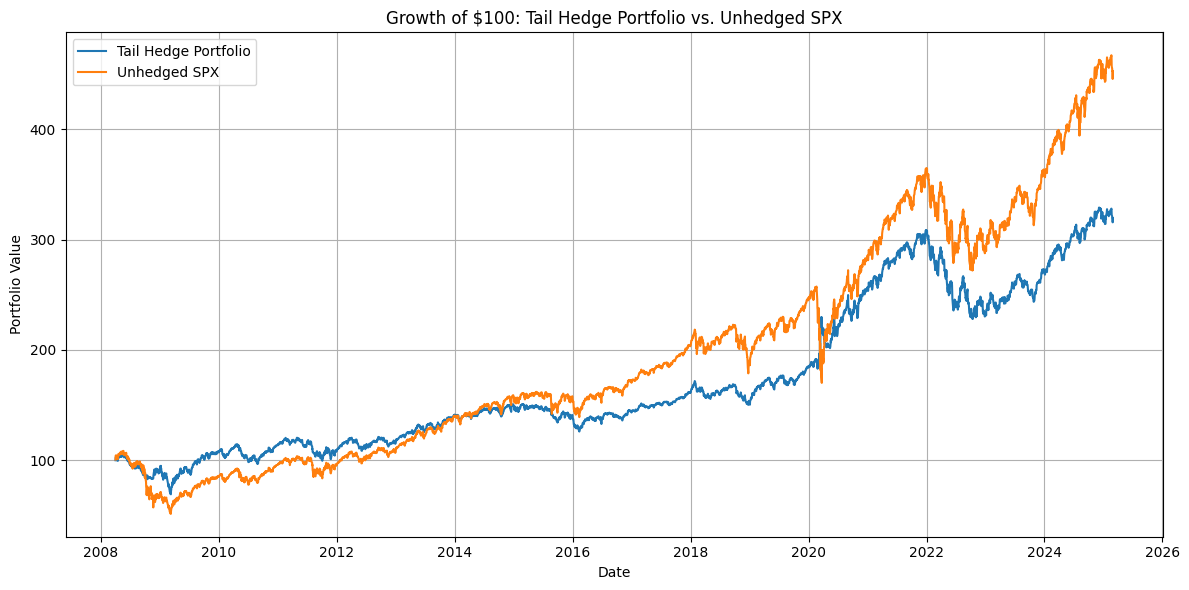

In [99]:
plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_ts.index,
    portfolio_ts["portfolio_value"],
    label="Tail Hedge Portfolio"
)

plt.plot(
    spx_ts.index,
    spx_ts["portfolio_value"],
    label="Unhedged SPX"
)

plt.title("Growth of $100: Tail Hedge Portfolio vs. Unhedged SPX")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

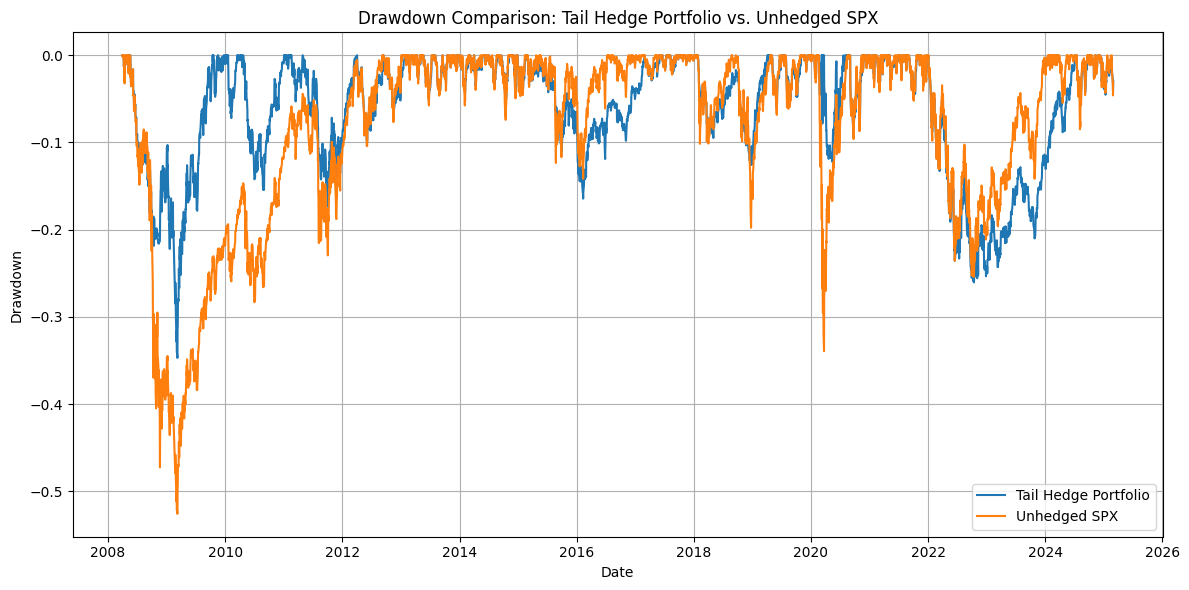

In [100]:
plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_ts.index,
    portfolio_ts["drawdown"],
    label="Tail Hedge Portfolio"
)

plt.plot(
    spx_ts.index,
    spx_ts["drawdown"],
    label="Unhedged SPX"
)

plt.title("Drawdown Comparison: Tail Hedge Portfolio vs. Unhedged SPX")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

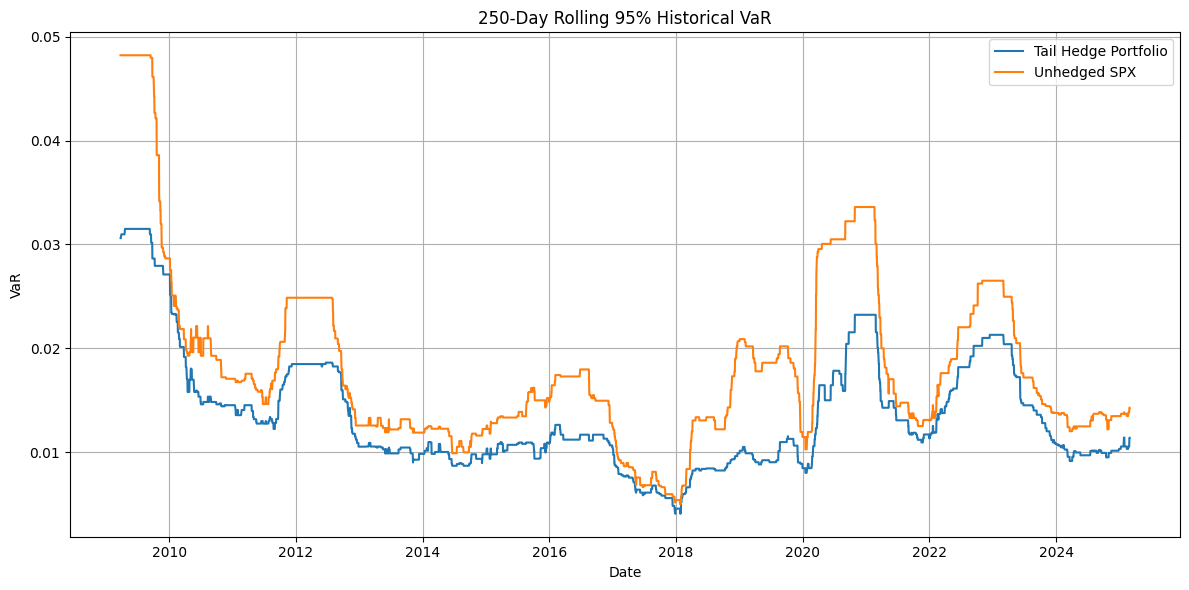

In [101]:
plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_ts.index,
    portfolio_ts["rolling_hvar_95"],
    label="Tail Hedge Portfolio"
)

plt.plot(
    spx_ts.index,
    spx_ts["rolling_hvar_95"],
    label="Unhedged SPX"
)

plt.title("250-Day Rolling 95% Historical VaR")
plt.xlabel("Date")
plt.ylabel("VaR")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

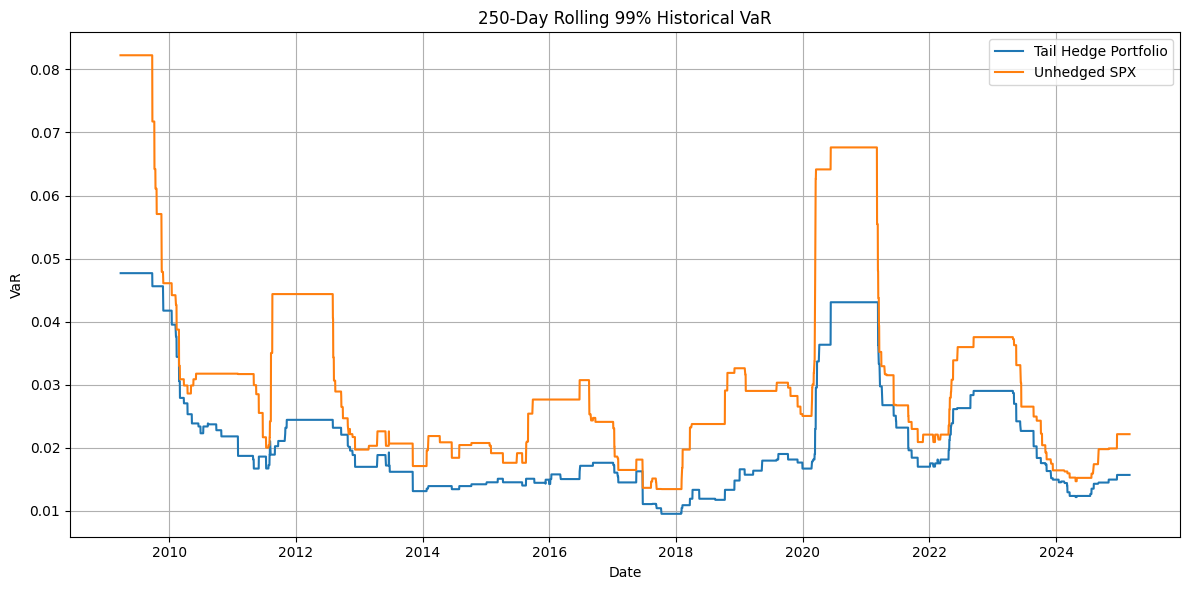

In [102]:
plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_ts.index,
    portfolio_ts["rolling_hvar_99"],
    label="Tail Hedge Portfolio"
)

plt.plot(
    spx_ts.index,
    spx_ts["rolling_hvar_99"],
    label="Unhedged SPX"
)

plt.title("250-Day Rolling 99% Historical VaR")
plt.xlabel("Date")
plt.ylabel("VaR")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

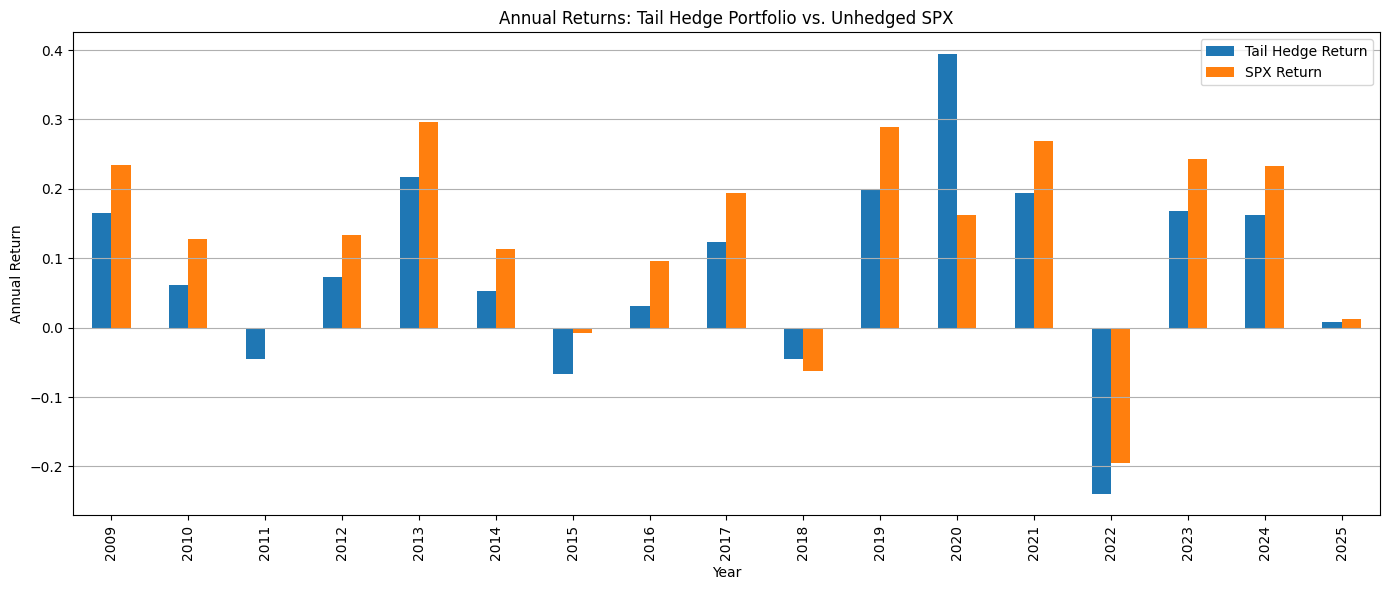

In [103]:
annual_returns_plot = annual_returns[
    ["Tail Hedge Return", "SPX Return"]
].copy()

annual_returns_plot.index = annual_returns_plot.index.year

annual_returns_plot.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Annual Returns: Tail Hedge Portfolio vs. Unhedged SPX")
plt.xlabel("Year")
plt.ylabel("Annual Return")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()

plt.show()

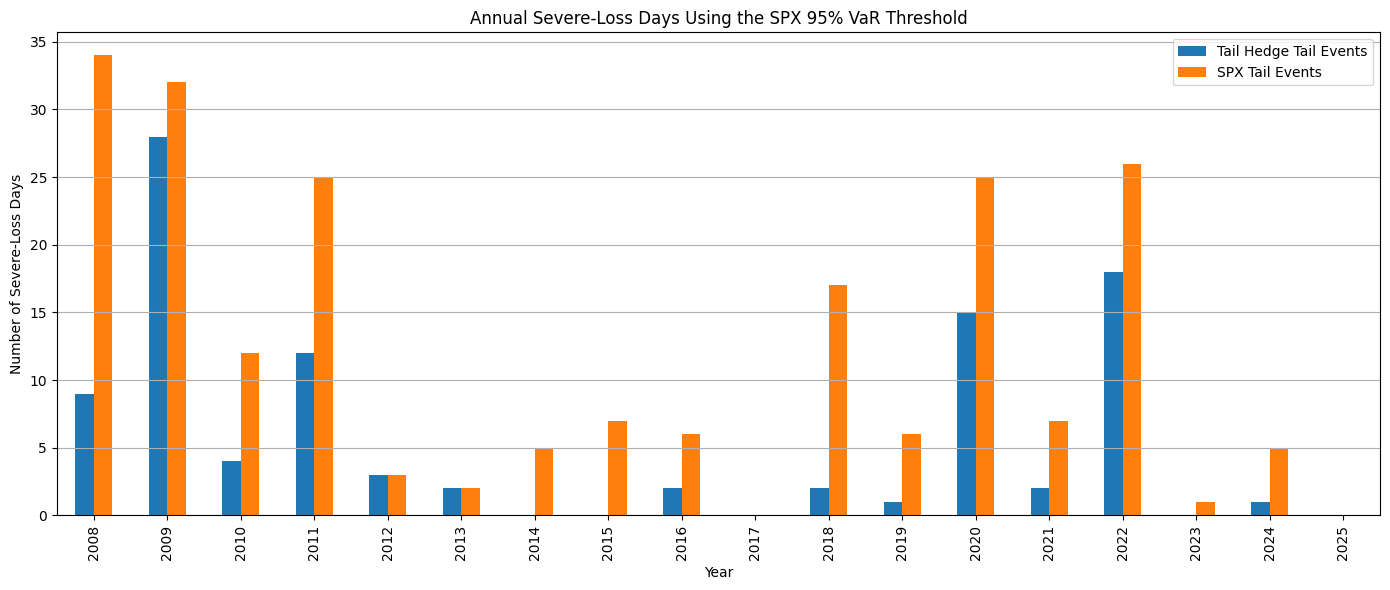

In [104]:
annual_common_tail_events.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Annual Severe-Loss Days Using the SPX 95% VaR Threshold")
plt.xlabel("Year")
plt.ylabel("Number of Severe-Loss Days")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()

plt.show()

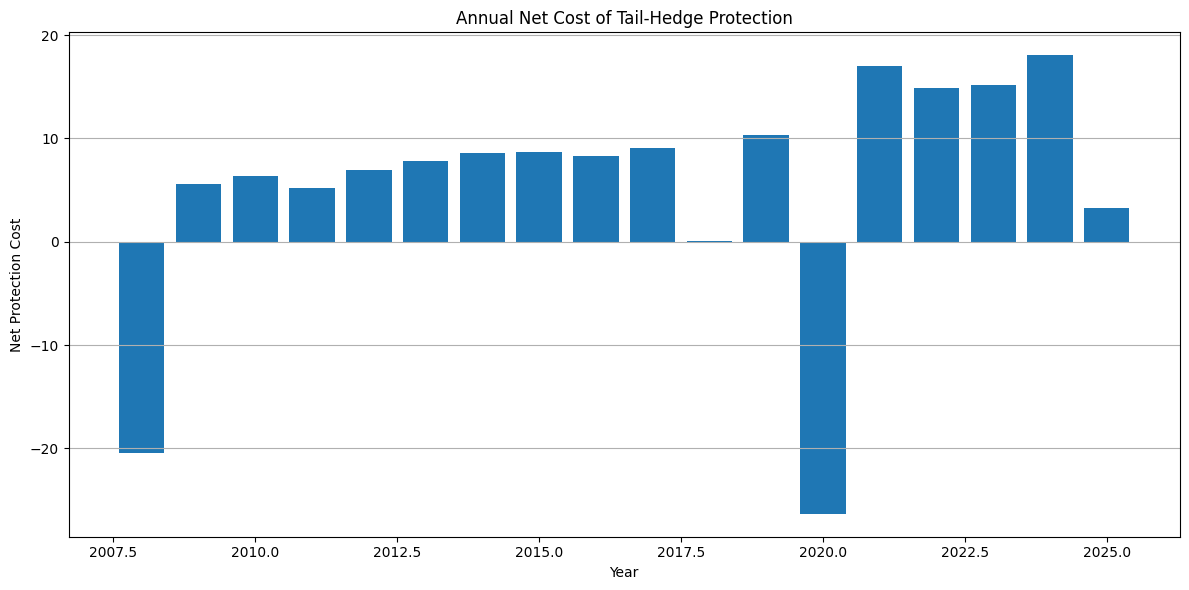

In [105]:
plt.figure(figsize=(12, 6))

plt.bar(
    annual_protection_cost["year"],
    annual_protection_cost["annual_net_protection_cost"]
)

plt.title("Annual Net Cost of Tail-Hedge Protection")
plt.xlabel("Year")
plt.ylabel("Net Protection Cost")
plt.grid(True, axis="y")
plt.tight_layout()

plt.show()

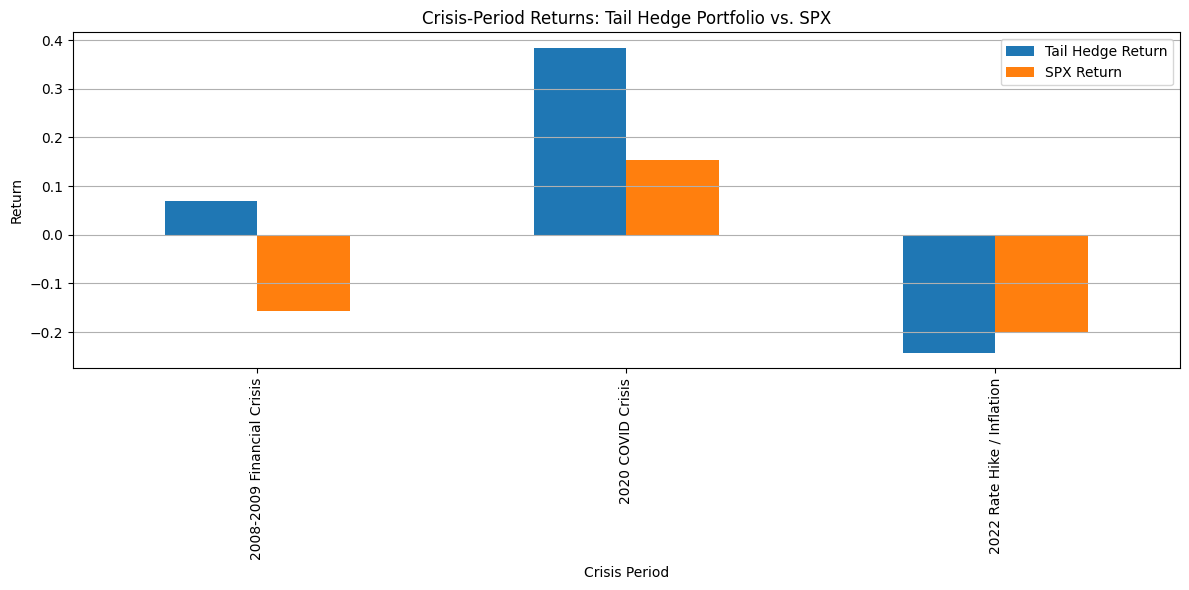

In [106]:
crisis_return_plot = crisis_comparison[
    ["Period", "Tail Hedge Return", "SPX Return"]
].copy()

crisis_return_plot = crisis_return_plot.set_index("Period")

crisis_return_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Crisis-Period Returns: Tail Hedge Portfolio vs. SPX")
plt.xlabel("Crisis Period")
plt.ylabel("Return")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()

plt.show()

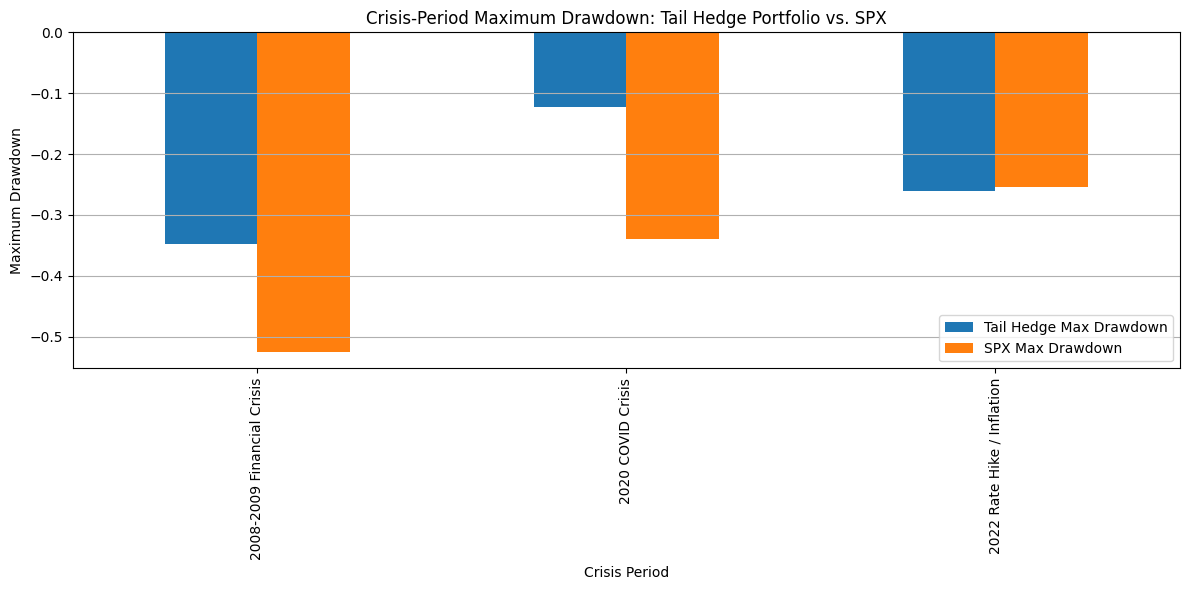

In [107]:
crisis_drawdown_plot = crisis_comparison[
    [
        "Period",
        "Tail Hedge Max Drawdown",
        "SPX Max Drawdown"
    ]
].copy()

crisis_drawdown_plot = crisis_drawdown_plot.set_index(
    "Period"
)

crisis_drawdown_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Crisis-Period Maximum Drawdown: "
    "Tail Hedge Portfolio vs. SPX"
)

plt.xlabel("Crisis Period")
plt.ylabel("Maximum Drawdown")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()

plt.show()

### Allocation sensitivity analysis
The interactive-widget installation cell was removed. The sensitivity test below uses fixed allocation levels and does not require `ipywidgets`.


In [108]:
def run_tail_hedge_backtest_fast(budget_per_leg):

    initial_option_budget = 100 * budget_per_leg
    test_spx_budget = 100 - initial_option_budget * 3
    test_spx_units = test_spx_budget / start_spx_price

    test_leg_units = {
        "leg_1": initial_option_budget / starting_row["leg_1_ask"],
        "leg_2": initial_option_budget / starting_row["leg_2_ask"],
        "leg_3": initial_option_budget / starting_row["leg_3_ask"]
    }

    test_leg_pointer = {
        "leg_1": 0,
        "leg_2": 0,
        "leg_3": 0
    }

    portfolio_values = [100.0]

    for i in range(1, len(masterdates)):

        current_date = masterdates.iloc[i]
        current_spx_price = spx.iloc[i]["closeprice"]
        current_prices = options_daily_prices.iloc[i]

        daily_marks = {
            leg: (
                current_prices[f"{leg}_bid"]
                + current_prices[f"{leg}_ask"]
            ) / 2
            for leg in ["leg_1", "leg_2", "leg_3"]
        }

        rolling_leg = None

        for leg in ["leg_1", "leg_2", "leg_3"]:

            current_contract = leg_tables[leg].iloc[
                test_leg_pointer[leg]
            ]

            if current_contract["roll_date"] == current_date:
                rolling_leg = leg
                break

        if rolling_leg is None:

            portfolio_value = (
                test_spx_units * current_spx_price
                + test_leg_units["leg_1"] * daily_marks["leg_1"]
                + test_leg_units["leg_2"] * daily_marks["leg_2"]
                + test_leg_units["leg_3"] * daily_marks["leg_3"]
            )

        else:

            replacement_pointer = (
                test_leg_pointer[rolling_leg] + 1
            )

            replacement_row = leg_tables[
                rolling_leg
            ].iloc[replacement_pointer]

            old_mark = (
                replacement_row["old_bid_price"]
                + replacement_row["old_ask_price"]
            ) / 2

            portfolio_value = (
                test_spx_units * current_spx_price
            )

            for leg in ["leg_1", "leg_2", "leg_3"]:

                if leg == rolling_leg:
                    portfolio_value += (
                        test_leg_units[leg] * old_mark
                    )
                else:
                    portfolio_value += (
                        test_leg_units[leg] * daily_marks[leg]
                    )

            new_option_budget = (
                portfolio_value * budget_per_leg
            )

            old_sale_proceeds = (
                test_leg_units[rolling_leg] * old_mark
            )

            test_spx_units += (
                old_sale_proceeds - new_option_budget
            ) / current_spx_price

            test_leg_units[rolling_leg] = (
                new_option_budget
                / replacement_row["ask_price"]
            )

            test_leg_pointer[rolling_leg] = (
                replacement_pointer
            )

        portfolio_values.append(portfolio_value)

    result = pd.DataFrame({
        "date": masterdates,
        "portfolio_value": portfolio_values
    })

    result = result.set_index("date")

    result["daily_return"] = (
        result["portfolio_value"].pct_change()
    )

    return result

In [109]:
start_spx_price = spx.iloc[0]["closeprice"]
starting_row = options_daily_prices.iloc[0]

print(start_spx_price)

1322.699951171875


In [112]:
allocation_levels = [
    0.00,
    0.015,
    0.05,
    0.10,
    0.25,
    0.50,
    1.00
]

sensitivity_results = []

for total_hedge_allocation in allocation_levels:
    budget_per_leg = total_hedge_allocation / 3

    test_result = run_tail_hedge_backtest_fast(
        budget_per_leg
    )

    test_returns = test_result["daily_return"].dropna()
    ending_value = test_result["portfolio_value"].iloc[-1]

    test_total_return = (
        ending_value
        / test_result["portfolio_value"].iloc[0]
    ) - 1

    if ending_value > 0:
        test_annualized_return = (
        ending_value / test_result["portfolio_value"].iloc[0]
    ) ** (252 / len(test_result)) - 1
    else:
        test_annualized_return = float("nan")

    test_volatility = test_returns.std() * np.sqrt(252)

    test_drawdown = (
        test_result["portfolio_value"]
        / test_result["portfolio_value"].cummax()
        - 1
    )

    sensitivity_results.append({
        "Total Hedge Allocation": total_hedge_allocation,
        "Allocation per Leg": budget_per_leg,
        "Ending Value": ending_value,
        "Total Return": test_total_return,
        "Annualized Return": test_annualized_return,
        "Annualized Volatility": test_volatility,
        "Maximum Drawdown": test_drawdown.min()
    })

allocation_sensitivity = pd.DataFrame(
    sensitivity_results
)

allocation_sensitivity


,Total Hedge Allocation,Allocation per Leg,Ending Value,Total Return,Annualized Return,Annualized Volatility,Maximum Drawdown
0,0.000,0.000000,4.501777e+02,3.501777,0.093123,0.200096,-0.525785
1,0.015,0.005000,3.193041e+02,2.193041,0.071125,0.147194,-0.347060
2,0.050,0.016667,8.801412e+01,-0.119859,-0.007528,0.267135,-0.608692
3,0.100,0.033333,7.506607e+00,-0.924934,-0.142082,0.445665,-0.964945
4,0.250,0.083333,4.249658e-04,-0.999996,-0.519059,0.886034,-0.999999
5,0.500,0.166667,9.821129e-15,-1.000000,-0.887121,1.621216,-1.000000
6,1.000,0.333333,-6.180969e-43,-1.000000,NaN,24.965624,-1.353737


The temporary repair cell that referenced the nonexistent variable `options` was removed.
